## Notebook for preprocessing and formatting the Joung data

In [34]:
# set up environment
import pandas as pd
import numpy as np
import scanpy as sc

In [35]:
# control panel
data_folder   = '../../../data/real/Joung2023/'
output_folder = '../../../data/real/Joung2023/'
tf_info_file  = data_folder + 'GRN/' + "hg38_TFinfo_dataframe_gimmemotifsv5_fpr2_threshold_10_20210630.parquet"

# parameters from notebook 2 — must match what was used there
top_percentage = 0.5    # fraction of top-ranked GRN edges retained
best_key       = 1.0    # best gamma_reg selected by stability analysis

# derived name components (mirrors notebook 2 convention)
_top_pct = int(top_percentage * 100)
_gamma   = str(best_key).replace('.', 'p')

unprocessed_data_file = data_folder + 'Joung2023.h5ad'
grn_genes_file        = data_folder + 'GRN/' + f'all_genes_{_top_pct}pct.txt'
tf_communities_file   = data_folder + 'GRN/' + f'tf_communities_{_top_pct}pct_gamma{_gamma}.csv'
processed_data_file   = output_folder + f'Joung2023_processed_{_top_pct}pct_gamma{_gamma}.h5ad'
pseudobulk_data_file  = output_folder + f'Joung2023_pseudobulk_{_top_pct}pct_gamma{_gamma}.h5ad'


In [36]:
# load data
adata = sc.read_h5ad(unprocessed_data_file)
tf_info = pd.read_parquet(tf_info_file)
grn_genes = pd.read_csv(grn_genes_file, header=None)[0].tolist()


### Preprocessing single cell data
Make sure we are using normalized, log transformed data

In [37]:
# check .X
print(adata.X.min())
print(adata.X.mean())
print(adata.X.max())


0.0
0.11078237
6.238893


## Restricting to genes in the GRN

In [38]:
# selecting only genes in the GRN
adata.var['gene_symbols'] = adata.var_names
adata = adata[:, adata.var.gene_symbols.isin(grn_genes)].copy()

### Formatting the adata.var data frame

In [39]:
# gene symbol
adata.var['gene_symbols'] = adata.var_names

# setting the "kind" column to indicate TFs and non-TFs
adata.var['kind'] = 'TG'
tf_names = set(tf_info.columns.unique())
adata.var.loc[adata.var.index.isin(tf_names), 'kind'] = 'TF'

# adding the community information to adata.var
tmp = pd.read_csv(tf_communities_file)
tf2latent = dict(zip(tmp["tf"], tmp["community"]))
adata.var['community'] =adata.var.index.map(tf2latent).astype('category')

# printing the adata.var to check
adata.var.loc[adata.var['kind'] == 'TF', :]

,highly_variable,means,dispersions,dispersions_norm,highly_variable_nbatches,highly_variable_intersection,mean,std,gene_symbols,kind,community
AR,True,0.503629,1.393478,0.629287,1,False,0.306680,0.596761,AR,TF,1.0
BACH2,True,0.611297,1.400013,0.840069,1,False,0.411292,0.673469,BACH2,TF,1.0
BARHL2,True,0.000412,1.473908,0.796735,2,True,0.000151,0.014714,BARHL2,TF,0.0
BARX2,True,0.003709,1.431747,0.513114,1,False,0.001427,0.044280,BARX2,TF,1.0
BCL11A,True,1.156206,1.404978,0.477720,1,False,0.948809,0.872071,BCL11A,TF,3.0
...,...,...,...,...,...,...,...,...,...,...,...
ZIC1,True,0.008515,1.420332,0.514292,1,False,0.003208,0.066632,ZIC1,TF,0.0
ZIC4,True,0.008732,1.445197,0.622566,2,True,0.004384,0.078169,ZIC4,TF,1.0
ZNF257,True,0.002601,1.404610,0.456309,1,False,0.001316,0.042887,ZNF257,TF,0.0
ZNF423,True,1.117003,1.419108,1.053977,2,True,0.785560,0.836021,ZNF423,TF,0.0


### Formatting the adata.obs data frame

In [40]:
# adding the cell type information to adata.obs
adata.obs['cell_type'] = 'hESC'

# adding and formatting the intervention column
adata.obs['intervention']  = adata.obs['TF_name'].copy().astype('str')
adata.obs.loc[:, 'intervention'] = adata.obs['intervention'].str.replace('ctrl', 'unperturbed', regex=False).astype('str')
adata.obs

,n_genes,percent_mito,n_counts,batch,TF,ORF_ID,TF_name,is_differentiated,is_combinatorially_tested,control_type,cell_type,intervention
"R1.01,R2.42,R3.02,P1.22-0-0",833,0.025510,980.0,0,TFORF1759-ALYREF,TFORF1759,ALYREF,False,False,NaN,hESC,ALYREF
"R1.01,R2.44,R3.22,P1.22-0-0",2283,0.025893,3360.0,0,TFORF1759-ALYREF,TFORF1759,ALYREF,False,False,NaN,hESC,ALYREF
"R1.01,R2.71,R3.40,P1.38-0-0",2060,0.028267,3007.0,0,TFORF1759-ALYREF,TFORF1759,ALYREF,False,False,NaN,hESC,ALYREF
"R1.02,R2.02,R3.33,P1.46-0-0",2669,0.028516,4138.0,0,TFORF1759-ALYREF,TFORF1759,ALYREF,False,False,NaN,hESC,ALYREF
"R1.02,R2.72,R3.42,P1.46-0-0",2054,0.022077,2899.0,0,TFORF1759-ALYREF,TFORF1759,ALYREF,False,False,NaN,hESC,ALYREF
...,...,...,...,...,...,...,...,...,...,...,...,...
"R1.67,R2.79,R3.19,P1.38-2-1",1866,0.018295,2569.0,1,TFORF3549-GFP,TFORF3549,ctrl,False,True,GFP,hESC,unperturbed
"R1.05,R2.21,R3.86,P1.38-2-1",3051,0.017558,4898.0,1,TFORF3550-mCherry,TFORF3550,ctrl,False,False,mCherry,hESC,unperturbed
"R1.37,R2.54,R3.81,P1.22-0-1",2316,0.021437,3312.0,1,TFORF3550-mCherry,TFORF3550,ctrl,False,False,mCherry,hESC,unperturbed
"R1.26,R2.35,R3.08,P1.30-1-1",2090,0.016741,2927.0,1,TFORF3550-mCherry,TFORF3550,ctrl,False,False,mCherry,hESC,unperturbed


### Restrict perturbations to TF that are (a) present in adata.var and (b) in a community

In [41]:
# get list of valid TFs 
idx = (adata.var['kind'] == 'TF') & (adata.var['community'].notna())
tf_list = set(adata.var[idx].index.tolist())

# function to check if all perturbed genes are TFs
def all_genes_are_tfs(intervention, tf_list):
    if intervention == 'unperturbed':
        return True
    # Split by '+' to handle both single and double perturbations
    genes = intervention.split('+')
    return all(gene in tf_list for gene in genes)

# apply filter
mask = adata.obs['intervention'].apply(lambda x: all_genes_are_tfs(x, tf_list))
adata = adata[mask, :].copy()

# print summary
print(f"Filtered cells: {adata.n_obs}")
print(f"Unique interventions retained: {adata.obs['intervention'].nunique()}")
print(adata.obs['intervention'].unique())

 # print adata for checking
adata

Filtered cells: 45072
Unique interventions retained: 40
['BHLHE22' 'DDIT3' 'DMRTC2' 'EHF' 'EMX2' 'ESRRG' 'FERD3L' 'FOXP1' 'FOXP3'
 'HMX1' 'HNF4G' 'HOXA7' 'HOXB7' 'HOXB8' 'ID3' 'IKZF3' 'KLF8' 'LHX6'
 'MEF2C' 'MEIS2' 'MITF' 'MSGN1' 'NFIB' 'NKX6-3' 'NR1H4' 'PAX3' 'PITX2'
 'PPARD' 'RARB' 'SCX' 'SHOX2' 'SMAD3' 'SP7' 'T' 'TCF21' 'TCF4' 'TEAD4'
 'VAX1' 'ZIC4' 'unperturbed']


AnnData object with n_obs × n_vars = 45072 × 1688
    obs: 'n_genes', 'percent_mito', 'n_counts', 'batch', 'TF', 'ORF_ID', 'TF_name', 'is_differentiated', 'is_combinatorially_tested', 'control_type', 'cell_type', 'intervention'
    var: 'highly_variable', 'means', 'dispersions', 'dispersions_norm', 'highly_variable_nbatches', 'highly_variable_intersection', 'mean', 'std', 'gene_symbols', 'kind', 'community'
    uns: 'hvg', 'log1p', 'neighbors', 'pca', 'umap'
    obsm: 'X_pca', 'X_umap'
    varm: 'PCs'
    layers: 'counts', 'lognorm'
    obsp: 'connectivities', 'distances'

In [42]:
# keeping only interventions with more than 100 cells

# quantifying the number of cells for each intervention 
int_cell_count = adata.obs['intervention'].value_counts() 

# which intervention to retain?
to_retain = int_cell_count[int_cell_count > 100].index.to_list()

# selection
adata = adata[adata.obs['intervention'].isin(to_retain)].copy()
adata

AnnData object with n_obs × n_vars = 45072 × 1688
    obs: 'n_genes', 'percent_mito', 'n_counts', 'batch', 'TF', 'ORF_ID', 'TF_name', 'is_differentiated', 'is_combinatorially_tested', 'control_type', 'cell_type', 'intervention'
    var: 'highly_variable', 'means', 'dispersions', 'dispersions_norm', 'highly_variable_nbatches', 'highly_variable_intersection', 'mean', 'std', 'gene_symbols', 'kind', 'community'
    uns: 'hvg', 'log1p', 'neighbors', 'pca', 'umap'
    obsm: 'X_pca', 'X_umap'
    varm: 'PCs'
    layers: 'counts', 'lognorm'
    obsp: 'connectivities', 'distances'

In [43]:
# checking communities
adata.var['community'].value_counts()

community
0.0    40
1.0    34
3.0    27
4.0    25
2.0    20
5.0     4
Name: count, dtype: int64

In [44]:
# Compute pseudobulks by averaging gene expression per intervention
pseudobulk_list = []
intervention_labels = []

for intervention in adata.obs['intervention'].unique():
    # Get cells for this intervention
    mask = adata.obs['intervention'] == intervention
    cells_subset = adata[mask, :]
    
    # Compute mean expression across cells
    mean_expr = cells_subset.X.mean(axis=0)
    if hasattr(mean_expr, 'A1'):  # Convert sparse matrix to array if needed
        mean_expr = mean_expr.A1
    
    pseudobulk_list.append(mean_expr)
    intervention_labels.append(intervention)

# Create pseudobulk matrix
pseudobulk_matrix = np.vstack(pseudobulk_list)

# Create AnnData object for pseudobulks
adata_pseudobulk = sc.AnnData(
    X=pseudobulk_matrix,
    obs=pd.DataFrame({'intervention': intervention_labels}),
    var=adata.var.copy()
)

print(f"Pseudobulk data shape: {adata_pseudobulk.shape}")
print(f"Number of interventions: {len(intervention_labels)}")
adata_pseudobulk

# saving
adata_pseudobulk.write_h5ad(pseudobulk_data_file)


Pseudobulk data shape: (40, 1688)
Number of interventions: 40


/home/laganiv/miniconda3/envs/deep_learning/lib/python3.10/site-packages/anndata/_core/aligned_df.py:68: ImplicitModificationWarning: Transforming to str index.
  warnings.warn("Transforming to str index.", ImplicitModificationWarning)


In [45]:
# Compute distances between each intervention and unperturbed cells in pseudobulk space
# Using MSE (Mean Squared Error) as in train_gcrl_vae.py centroid loss

# Get unperturbed pseudobulk
unperturbed_mask = adata_pseudobulk.obs['intervention'] == 'unperturbed'
unperturbed_pseudobulk = adata_pseudobulk.X[unperturbed_mask]

if len(unperturbed_pseudobulk) == 0:
    print("Warning: No unperturbed cells found in pseudobulk data")
else:
    # Should have exactly one unperturbed pseudobulk
    unperturbed_centroid = unperturbed_pseudobulk[0]  # (n_genes,)
    
    # Compute MSE distance for each intervention
    distances = []
    intervention_names = []
    
    for i, intervention in enumerate(adata_pseudobulk.obs['intervention']):
        intervention_centroid = adata_pseudobulk.X[i]  # (n_genes,)
        
        # MSE distance (same as in train_gcrl_vae.py line 1442)
        mse_distance = np.mean((intervention_centroid - unperturbed_centroid) ** 2)
        
        distances.append(mse_distance)
        intervention_names.append(intervention)
    
    # Create DataFrame with results
    distance_df = pd.DataFrame({
        'intervention': intervention_names,
        'mse_distance_to_unperturbed': distances
    })
    
    # Sort by distance (ascending)
    distance_df = distance_df.sort_values('mse_distance_to_unperturbed', ascending=True)
    
    print("\nDistances from unperturbed (sorted by distance):")
    print("=" * 60)
    print(distance_df.to_string(index=False))
    print("=" * 60)
    print(f"\nMean distance: {distance_df[distance_df['intervention'] != 'unperturbed']['mse_distance_to_unperturbed'].mean():.6f}")
    print(f"Std distance: {distance_df[distance_df['intervention'] != 'unperturbed']['mse_distance_to_unperturbed'].std():.6f}")
    print(f"Min distance (excluding unperturbed): {distance_df[distance_df['intervention'] != 'unperturbed']['mse_distance_to_unperturbed'].min():.6f}")
    print(f"Max distance: {distance_df[distance_df['intervention'] != 'unperturbed']['mse_distance_to_unperturbed'].max():.6f}")



Distances from unperturbed (sorted by distance):
intervention  mse_distance_to_unperturbed
 unperturbed                     0.000000
      FERD3L                     0.000900
       MSGN1                     0.001218
           T                     0.004995
       HNF4G                     0.013734
        MITF                     0.025257
        TCF4                     0.029252
        NFIB                     0.032172
         SCX                     0.036245
       IKZF3                     0.036944
       FOXP1                     0.038416
       PITX2                     0.038519
       FOXP3                     0.038807
        VAX1                     0.038986
       HOXB7                     0.039103
       SHOX2                     0.039415
         ID3                     0.039446
        ZIC4                     0.039449
       PPARD                     0.039480
        HMX1                     0.039515
     BHLHE22                     0.039641
        EMX2              

Pearson  r = -0.843,  p = 1.623e-11
Spearman r = -0.453,  p = 3.810e-03


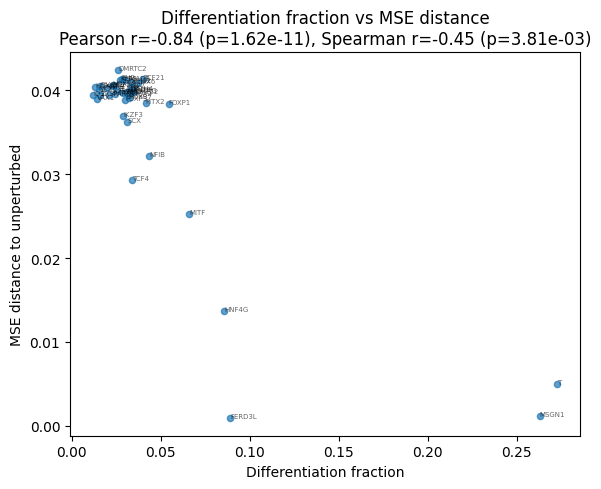

In [46]:
from scipy.stats import pearsonr, spearmanr
import matplotlib.pyplot as plt

# Compute differentiation fraction per intervention (excluding unperturbed)
diff_frac = (
    adata.obs[adata.obs['intervention'] != 'unperturbed']
    .groupby('intervention')['is_differentiated']
    .mean()
    .rename('diff_fraction')
)

# Merge with distance_df (exclude unperturbed row)
corr_df = (
    distance_df[distance_df['intervention'] != 'unperturbed']
    .set_index('intervention')
    .join(diff_frac)
    .dropna()
    .reset_index()
)

# Pearson and Spearman correlations
r_pearson, p_pearson = pearsonr(corr_df['diff_fraction'], corr_df['mse_distance_to_unperturbed'])
r_spearman, p_spearman = spearmanr(corr_df['diff_fraction'], corr_df['mse_distance_to_unperturbed'])

print(f"Pearson  r = {r_pearson:.3f},  p = {p_pearson:.3e}")
print(f"Spearman r = {r_spearman:.3f},  p = {p_spearman:.3e}")

# Scatter plot
fig, ax = plt.subplots(figsize=(6, 5))
ax.scatter(corr_df['diff_fraction'], corr_df['mse_distance_to_unperturbed'], s=20, alpha=0.7)
for _, row in corr_df.iterrows():
    ax.annotate(row['intervention'], (row['diff_fraction'], row['mse_distance_to_unperturbed']),
                fontsize=5, alpha=0.6)
ax.set_xlabel('Differentiation fraction')
ax.set_ylabel('MSE distance to unperturbed')
ax.set_title(f'Differentiation fraction vs MSE distance\n'
             f'Pearson r={r_pearson:.2f} (p={p_pearson:.2e}), '
             f'Spearman r={r_spearman:.2f} (p={p_spearman:.2e})')
plt.tight_layout()
plt.show()

### Visualization

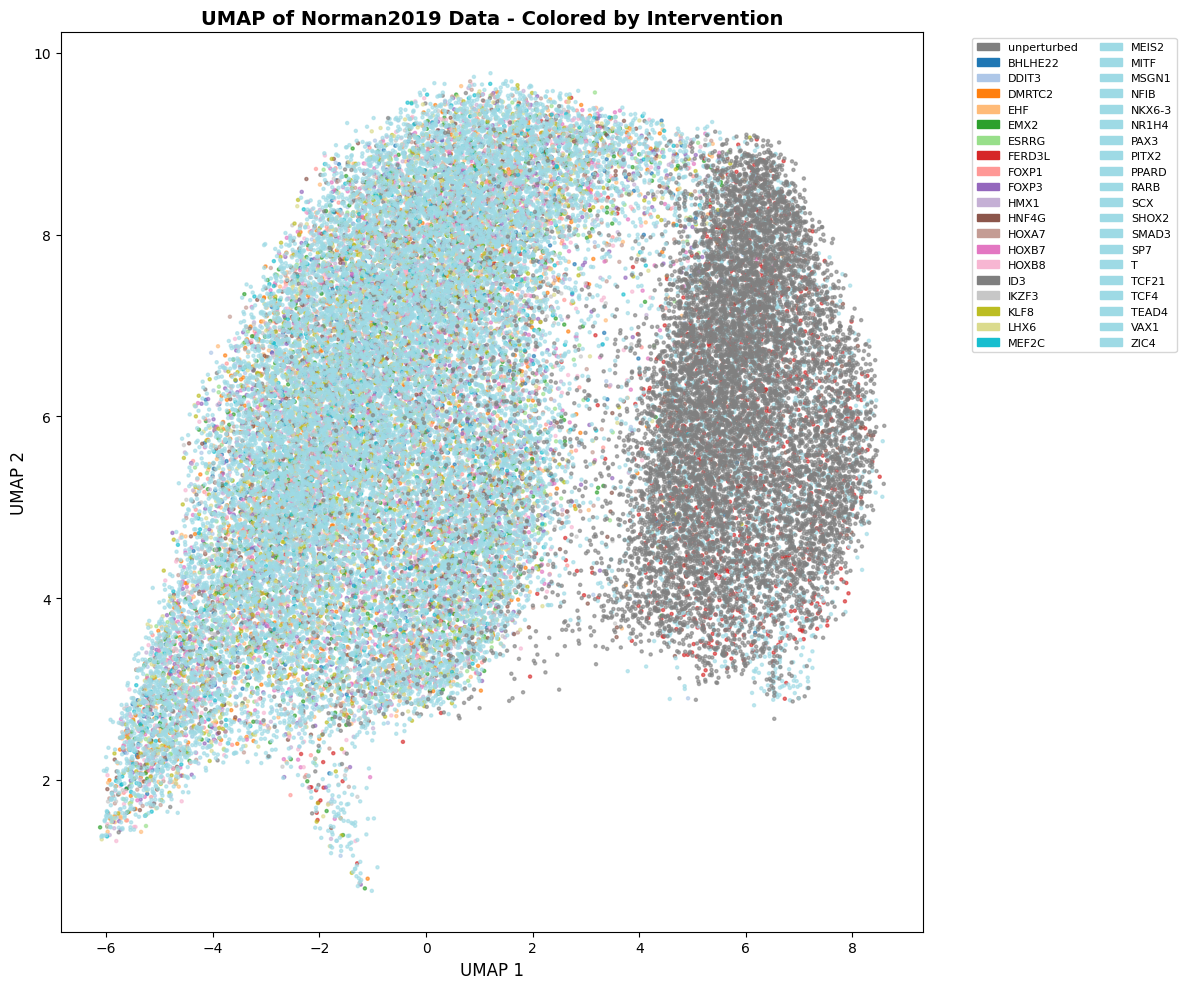

In [47]:
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches

# Compute PCA (required for UMAP)
sc.tl.pca(adata)

# Compute UMAP
sc.pp.neighbors(adata, n_neighbors=15, n_pcs=50)
sc.tl.umap(adata)

# Create color mapping: unperturbed in grey, others in distinct colors
interventions = adata.obs['intervention'].unique()
n_interventions = len(interventions)

# Generate color palette
color_palette = plt.cm.tab20(range(n_interventions))

# Create color map dictionary
intervention_colors = {}
for i, intervention in enumerate(sorted(interventions)):
    if intervention == 'unperturbed':
        intervention_colors[intervention] = '#808080'  # grey
    else:
        intervention_colors[intervention] = color_palette[i]

# Map colors to cells
cell_colors = [intervention_colors[intervention] for intervention in adata.obs['intervention']]

# Create the plot
fig, ax = plt.subplots(figsize=(12, 10))

# Plot UMAP
scatter = ax.scatter(
    adata.obsm['X_umap'][:, 0],
    adata.obsm['X_umap'][:, 1],
    c=cell_colors,
    s=5,
    alpha=0.6
)

ax.set_xlabel('UMAP 1', fontsize=12)
ax.set_ylabel('UMAP 2', fontsize=12)
ax.set_title('UMAP of Norman2019 Data - Colored by Intervention', fontsize=14, fontweight='bold')

# Create legend (only show subset to avoid overcrowding)
legend_elements = []
for intervention in sorted(interventions):
    if intervention == 'unperturbed':
        legend_elements.insert(0, mpatches.Patch(color=intervention_colors[intervention], label=intervention))
    else:
        legend_elements.append(mpatches.Patch(color=intervention_colors[intervention], label=intervention))

# Add legend with smaller font and multiple columns
ax.legend(handles=legend_elements, bbox_to_anchor=(1.05, 1), loc='upper left', 
          fontsize=8, ncol=2, frameon=True)

plt.tight_layout()
plt.show()

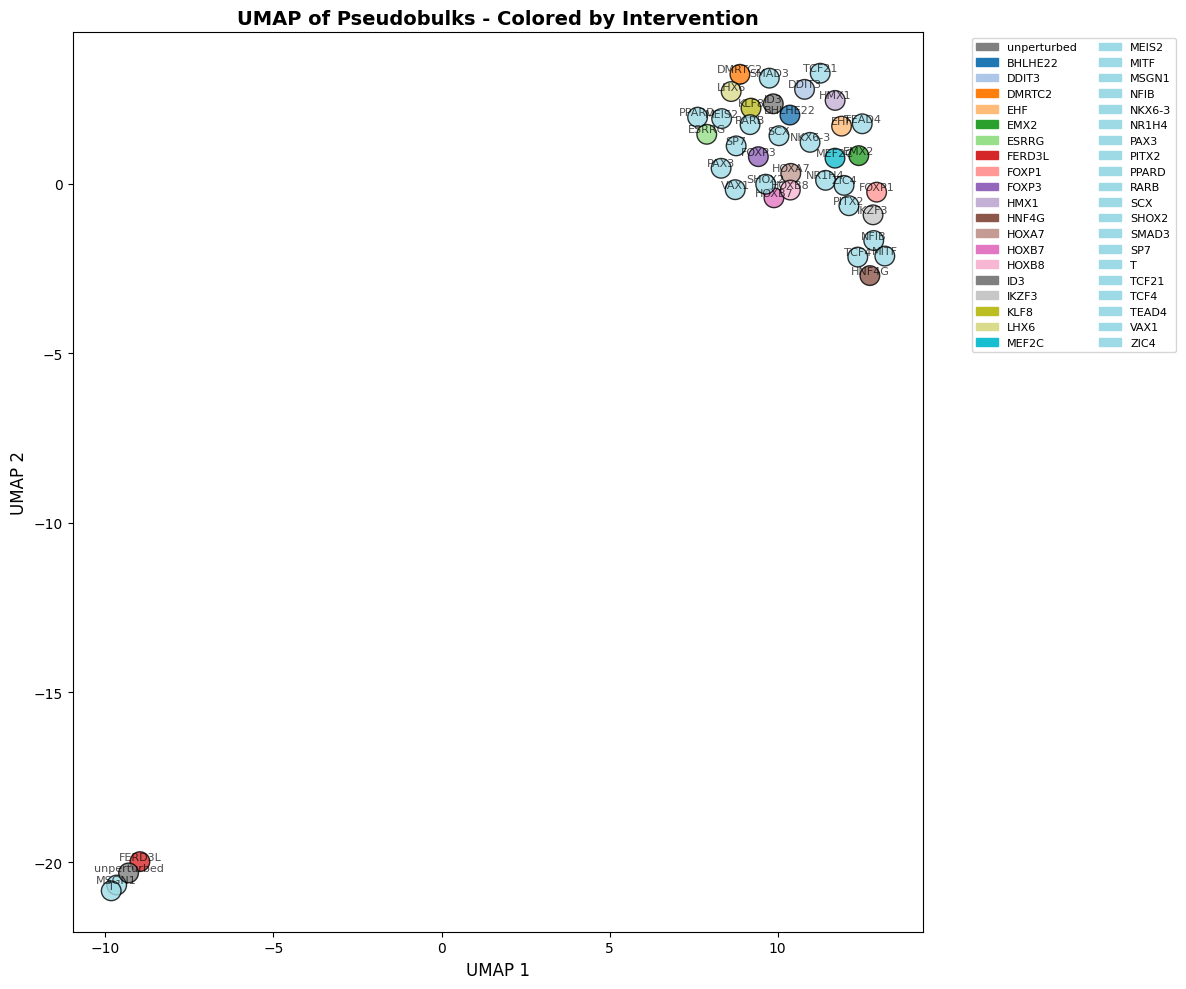

In [48]:
# Compute PCA for pseudobulks
sc.tl.pca(adata_pseudobulk)

# Compute UMAP for pseudobulks
sc.pp.neighbors(adata_pseudobulk, n_neighbors=5, n_pcs=20)
sc.tl.umap(adata_pseudobulk)

# Use same color scheme as before
pseudobulk_colors = [intervention_colors[intervention] for intervention in adata_pseudobulk.obs['intervention']]

# Create the plot
fig, ax = plt.subplots(figsize=(12, 10))

# Plot UMAP
scatter = ax.scatter(
    adata_pseudobulk.obsm['X_umap'][:, 0],
    adata_pseudobulk.obsm['X_umap'][:, 1],
    c=pseudobulk_colors,
    s=200,
    alpha=0.8,
    edgecolors='black',
    linewidth=1
)

# Add labels for each point
for i, intervention in enumerate(adata_pseudobulk.obs['intervention']):
    ax.annotate(
        intervention,
        (adata_pseudobulk.obsm['X_umap'][i, 0], adata_pseudobulk.obsm['X_umap'][i, 1]),
        fontsize=8,
        ha='center',
        va='bottom',
        alpha=0.7
    )

ax.set_xlabel('UMAP 1', fontsize=12)
ax.set_ylabel('UMAP 2', fontsize=12)
ax.set_title('UMAP of Pseudobulks - Colored by Intervention', fontsize=14, fontweight='bold')

# Add legend
legend_elements = []
for intervention in sorted(adata_pseudobulk.obs['intervention'].unique()):
    if intervention == 'unperturbed':
        legend_elements.insert(0, mpatches.Patch(color=intervention_colors[intervention], label=intervention))
    else:
        legend_elements.append(mpatches.Patch(color=intervention_colors[intervention], label=intervention))

ax.legend(handles=legend_elements, bbox_to_anchor=(1.05, 1), loc='upper left', 
          fontsize=8, ncol=2, frameon=True)

plt.tight_layout()
plt.show()

### Saving

In [49]:
# saving to output file
adata.write_h5ad(processed_data_file)
print(f'Saved processed data → {processed_data_file}')

Saved processed data → ../../../data/real/Joung2023/Joung2023_processed_50pct_gamma1p0.h5ad
